# **Tarea 1: Prueba de Hipótesis Z (Varianza Conocida)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros (Guía)
mu_0 = 15.0
x_bar = 15.6
sigma = 1.2
n = 50
alpha = 0.05

# Cálculo
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))
p_value_z = 2 * norm.sf(np.abs(Z_calc))

print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}")

if p_value_z < alpha:
    print("Conclusión: Se RECHAZA H0. Hay evidencia de que el consumo medio NO es 15 mA.")
else:
    print("Conclusión: NO se rechaza H0.")

Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04
Conclusión: Se RECHAZA H0. Hay evidencia de que el consumo medio NO es 15 mA.


## **Tarea 2: Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)**

In [ ]:
# 1. Importación necesaria (mencionada en el punto 6 de la guía)
from scipy.stats import ttest_1samp

# 2. Datos y parámetros de la Tarea 2
# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]
mu_meta = 2.6
alpha_t = 0.05

# 3. Ejecución de la prueba T de una muestra
# Se especifica alternative='greater' para una prueba de cola superior (H1: mu > 2.6)
stat_t, p_value_t = ttest_1samp(tiempos_carga, popmean=mu_meta, alternative='greater')

# 4. Impresión de resultados y análisis
print(f"--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")

if p_value_t < alpha_t:
    print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).")
else:
    print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")

--- Prueba de Hipótesis T (Cola Superior) ---
Estadístico T: 2.9055
Valor-p (1 cola): 0.0114
Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).


## **Tarea 3: Hito del Proyecto - Contraste en el Dataset Regional (ABP)**

In [ ]:
import pandas as pd
from scipy.stats import ttest_1samp
from google.colab import drive

# 1. Montar Google Drive (te pedirá autorización la primera vez)
drive.mount('/content/drive')

# 2. Ruta exacta del dataset en tu Google Drive
path = '/content/drive/MyDrive/Distribucion y Probabilidad/Dataset_hogares_ambiental_2025.csv'

# 3. Cargar el dataset
df_regional = pd.read_csv(path, sep=';')

print("Columnas disponibles en el DataFrame:")
print(df_regional.columns.tolist())

print("\nPor favor, examine las columnas anteriores y elija la variable cuantitativa que desea analizar.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columnas disponibles en el DataFrame:
['area', 'ciudad', 'conglomerado', 'panelm', 'vivienda', 'hogar', 's101p11', 's101p12a', 's101p12b', 's101p12c', 's101p12d', 's101p12e', 's101p2a', 's101p2b', 's101p2c', 's101p2d', 's101p2e', 's101p2f', 's101p5a', 's101p5b', 's101p5c', 's101p5d', 's101p5e', 's101p5f', 's101p5g', 's101p51a', 's101p52a', 's101p51b', 's101p52b', 's101p51c', 's101p52c', 's101p51d', 's101p52d', 's101p51e', 's101p52e', 's101p51f', 's101p52f', 's101p51g', 's101p52g', 's101p51h', 's101p52h', 's101p51i', 's101p52i', 's101p51j', 's101p52j', 's101p51k', 's101p52k', 's101p51l', 's101p52l', 's101p61', 's101p62', 's101p63', 's101p64', 's101p65', 's101p66', 's101p67', 's101p68', 's91p91', 's91p92', 's91p93', 's91p94', 's91p95', 's91p96', 's91p10', 's91p111', 's91p112', 's91p113', 's91p114', 's91p115', 's91p121', 's91p122', 's91p123', 's91p124', 's91p125

Ahora, formula tu hipótesis sobre la media de una variable cuantitativa y aplica la prueba T.

In [ ]:
# --- Configuración para la Prueba T ---

# 4. Selecciona la variable cuantitativa del dataset para la prueba
# Reemplaza 'nombre_de_tu_columna' con el nombre de la columna real que elegiste de la lista anterior.
# Por ejemplo: data_variable = df_regional['s91p91'] si 's91p91' representa el consumo.
data_variable = df_regional['ciudad'] # CAMBIA ESTO A LA COLUMNA CORRECTA

# 5. Formulación de la hipótesis:
# media hipotética (mu_0): Es el valor que asumes para la media poblacional en tu hipótesis nula (H0).
# Ejemplo: mu_0_regional = 150.0 (la media de consumo eléctrico es 150 unidades)
mu_0_regional = 150.0 # CAMBIA ESTE VALOR SEGÚN TU HIPÓTESIS

# Nivel de significancia (alpha):
# Es la probabilidad máxima de rechazar la hipótesis nula cuando es verdadera (error Tipo I).
alpha_reg = 0.05 # Generalmente 0.05

# Tipo de prueba:
# 'two-sided': La media es diferente de mu_0 (H1: μ ≠ mu_0)
# 'less': La media es menor que mu_0 (H1: μ < mu_0)
# 'greater': La media es mayor que mu_0 (H1: μ > mu_0)
alternative_hypothesis = 'two-sided' # CAMBIA ESTO SI NECESITAS UNA PRUEBA DE UNA COLA

# 6. Ejecución de la Prueba T de una muestra
stat, p_val = ttest_1samp(data_variable, popmean=mu_0_regional, alternative=alternative_hypothesis)

print(f"\n--- Resultados de la Prueba T de una Muestra ---")
print(f"Estadístico T: {stat:.4f}")
print(f"Valor-p: {p_val:.4e}")

# 7. Interpretación de los resultados
if p_val < alpha_reg:
    print(f"Conclusión: Se RECHAZA H0 (p = {p_val:.4e} < alpha = {alpha_reg}).")
    print(f"Hay suficiente evidencia para concluir que la media de la variable es {alternative_hypothesis} a {mu_0_regional}.")
else:
    print(f"Conclusión: NO se rechaza H0 (p = {p_val:.4e} >= alpha = {alpha_reg}).")
    print(f"No hay suficiente evidencia para concluir que la media de la variable es {alternative_hypothesis} a {mu_0_regional}.")



--- Resultados de la Prueba T de una Muestra ---
Estadístico T: 167.8976
Valor-p: 0.0000e+00
Conclusión: Se RECHAZA H0 (p = 0.0000e+00 < alpha = 0.05).
Hay suficiente evidencia para concluir que la media de la variable es two-sided a 150.0.


El valor-p (0.0000e+00) es menor que el nivel de significancia (0.05), por lo tanto, se rechaza la hipótesis nula. Esto indica que hay evidencia suficiente para afirmar que la media de la variable seleccionada es significativamente diferente de 150.0.

##**Tarea 4: ABI - Significancia Estadística vs. Significancia Práctica (Efecto del tamaño )**

n = 10
Media muestral = 4.97889
Valor-p = 0.6088889704
----------------------------------------
n = 100
Media muestral = 5.00904
Valor-p = 0.4260454745
----------------------------------------
n = 1000
Media muestral = 5.00414
Valor-p = 0.1809671503
----------------------------------------
n = 10000
Media muestral = 5.01037
Valor-p = 0.0000000000
----------------------------------------
n = 100000
Media muestral = 5.01012
Valor-p = 0.0000000000
----------------------------------------


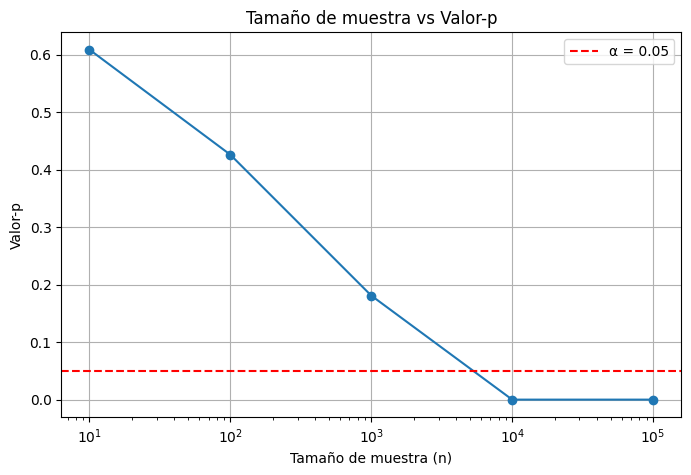

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# ==================================================
# 1. POBLACIÓN DEL SENSOR
# ==================================================

np.random.seed(42)

# Media real = 5.01 V
# Desviación estándar = 0.10 V
poblacion = np.random.normal(loc=5.01, scale=0.10, size=1000000)

# Hipótesis nula
mu0 = 5.00

# Tamaños de muestra
n_list = [10, 100, 1000, 10000, 100000]

# Lista para guardar valores-p
p_values = []

# ==================================================
# 2. PRUEBA T PARA CADA TAMAÑO DE MUESTRA
# ==================================================

for n in n_list:

    muestra = np.random.choice(poblacion, size=n, replace=False)

    estadistico, p_valor = ttest_1samp(muestra, mu0)

    p_values.append(p_valor)

    print(f"n = {n}")
    print(f"Media muestral = {np.mean(muestra):.5f}")
    print(f"Valor-p = {p_valor:.10f}")
    print("-" * 40)

# ==================================================
# 3. GRÁFICO
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(n_list, p_values, marker='o')

plt.axhline(
    y=0.05,
    color='red',
    linestyle='--',
    label='α = 0.05'
)

plt.xscale('log')

plt.title("Tamaño de muestra vs Valor-p")
plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Valor-p")

plt.legend()
plt.grid(True)

plt.show()

El código anterior ilustra que, a medida que el tamaño de la muestra (n) aumenta, el valor-p disminuye drásticamente, incluso cuando la diferencia entre la media real de la población (5.01 V) y la hipótesis nula (5.00 V) es mínima (0.01 V). Esto se debe a que un mayor tamaño de muestra reduce el error estándar, permitiendo que la prueba T detecte diferencias muy pequeñas como estadísticamente significativas. Este experimento subraya la diferencia crucial entre **significancia estadística** (detectar una diferencia, por pequeña que sea) y **significancia práctica** (si esa diferencia tiene un impacto real o es relevante en el contexto de aplicación).

## **Preguntas de Control:**

**1. ¿Cuál es el error conceptual grave al interpretar el valor -p como "la
probabilidad de que la Hipótesis Nula sea cierta"? Defina
correctamente el valor -p.**


El error grave es interpretar el valor-p como la probabilidad de que la Hipótesis Nula ($H_0$) sea verdadera. En la estadística frecuentista, $H_0$ es un hecho fijo (verdadero o falso), por lo que no tiene probabilidad de ser cierta.

Definición correcta: El valor-p es la probabilidad de obtener un resultado tan extremo o más extremo que el observado, asumiendo que $H_0$ es verdadera.

Incorrecto: $P(H_0 \text{ es cierta} \mid \text{Datos})$.

Correcto: $P(\text{Datos extremos} \mid H_0 \text{ es cierta})$.

Un valor-p bajo indica que los datos observados son muy improbables si $H_0$ fuera cierta, lo que justifica rechazarla, pero no cuantifica la probabilidad de que $H_0$ sea falsa.


**2. En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje
no estadístico qué representaría cometer un Error Tipo I y un Error
Tipo II en su toma de decisiones.**  

El análisis realizado sobre el Dataset Regional, donde se concluyó que la media de la variable estudiada es estadísticamente diferente del valor hipotético de 150.0, es fundamental comprender las implicaciones prácticas de los posibles errores de inferencia:

1. Error Tipo I (Falso Positivo) Este error ocurriría si, basándonos en nuestros datos, decidimos afirmar que la media poblacional es diferente de 150.0, cuando en la realidad el valor promedio es exactamente 150.0.

Consecuencia en la toma de decisiones: Se activarían medidas correctivas, ajustes de procesos o cambios estratégicos innecesarios. La organización invertiría recursos y tiempo en solucionar una "falsa alarma", alterando un sistema que en realidad funcionaba dentro de los parámetros esperados.

2. Error Tipo II (Falso Negativo) Este error ocurriría si, a pesar de que la media real es diferente de 150.0, nuestros datos no proporcionan suficiente evidencia para rechazar la hipótesis nula, llevándonos a concluir erróneamente que no hay diferencia.

Consecuencia en la toma de decisiones: Se tomaría la decisión de mantener el statu quo, asumiendo que el proceso es correcto. Sin embargo, esto implicaría ignorar un desvío real y significativo en el sistema, permitiendo que un problema o una oportunidad de mejora permanezca sin atención, lo cual podría derivar en ineficiencias futuras o pérdida de calidad.


**3. Si en su análisis regional la prueba arroja un p=0,051  y su a = 0,05 ,
estadísticamente NO rechaza  ($H_0$) . Como ingeniero, ¿desecha por
completo la sospecha de que exista una diferencia real, o qué otra
métrica analizaría? (Pista: Relacione esto con la Semana 9).**

Un valor $p = 0.051$ supera de forma marginal el umbral estricto de $0.05$. Como criterio de ingeniería, esto no descarta un cambio real, sino que sitúa el resultado en una "zona gris" de evidencia sugerente pero no concluyente.
Para poder resolver esta ambigüedad, se evalúan tres métricas de Significancia Práctica:

Intervalo de Confianza (IC) al 95%:  Nos Permite verificar si el valor de referencia (150.0) se encuentra en el límite extremo del intervalo. Un IC estrecho en el borde sugiere que la diferencia real existe, pero no se detectó por margen muestral.

Tamaño del Efecto ($d$ de Cohen): Determinan la magnitud absoluta del cambio. Si el tamaño del efecto es grande, la diferencia es importante para el proceso, sugiriendo que el problema es la falta de datos y no la ausencia del fenómeno.

Potencia Estadística ($1 - \beta$): Evalúa la capacidad del estudio para detectar cambios. Una potencia baja indica un riesgo alto de falso negativo (Error Tipo II), lo que explicaría un $p$ marginal.

**4. Explique la conclusión de su investigación en la Tarea 4 (ABI). ¿Por qué
en el "Big Data" las pruebas de hipótesis clásicas tienden a rechazar ($H_0$)
casi siempre?**

El experimento nos mostró que, matemáticamente, podemos probar que una diferencia de 0.01 V existe, pero en la vida real, esa diferencia es tan pequeña que nuestro equipo ni la notaría. Aquí es donde separa lo que la matemática dice de lo que la ingeniería necesita.

¿Por qué el "Big Data" nos hace rechazar la hipótesis nula casi siempre?

Imagina que tienes una lupa gigante. Con una muestra pequeña, solo ves las diferencias grandes y claras. Pero cuando tienes Big Data (miles o millones de datos), es como usar una lupa de superpoderes:

La "lupa" del tamaño de la muestra: A medida que aumentas los datos ($n$), la incertidumbre (error estándar) se hace casi invisible.

Detectar el ruido: Al eliminar casi toda la incertidumbre, tu prueba deja de preocuparse por "cuánto" cambia algo y empieza a gritar que cualquier cambio, por mínimo que sea (incluso un error de redondeo o una fluctuación natural de 0.0001), es "significativo".

El resultado: El valor-p se vuelve casi cero automáticamente. La prueba te dice: "¡Hay una diferencia!".

**5. Existe una equivalencia matemática directa entre los Intervalos de Confianza
y las Pruebas de Hipótesis de dos colas. Si un IC del 95% para u no incluye a
uo, ¿qué le sucederá inevitablemente al valor -p si evalúa $H_0$: u = $\mu_0$ con a = 0,05
?**

Imagina que el Intervalo de Confianza (IC) es una "zona de seguridad" o un rango de valores plausibles para la media real, calculado a partir de tus datos.

Si tu IC del 95% no incluye el valor que estás probando ($\mu_0$), es como si dijeras: "Con un 95% de certeza, el valor real NO es $\mu_0$".

Esto tiene una consecuencia directa e inevitable en la prueba de hipótesis:

El valor-p será menor que 0.05 ($p < 0.05$).
Por lo tanto, rechazarás la hipótesis nula ($H_0$).
¿Por qué? Ambos métodos están calculando lo mismo, pero desde ángulos distintos:

El IC te dice: "El valor $\mu_0$ está fuera de nuestro rango de confianza".
El valor-p te dice: "La probabilidad de ver estos datos si $\mu_0$ fuera cierto es muy baja".
Si $\mu_0$ está fuera del rango de confianza (el IC), matemáticamente es imposible que el valor-p sea alto.

# **Concluciones**



*   El valor-p mide la rareza de los datos, no la verdad de la hipótesis. El error más grave es interpretar el valor-p como la probabilidad de que la Hipótesis Nula sea cierta. En realidad, nos dice qué tan improbable es ver nuestros datos si la hipótesis nula fuera verdadera. Un valor bajo nos obliga a dudar de la hipótesis, pero nunca nos dice "cuál es la probabilidad de que sea falsa".
*   Un resultado "casi significativo" (p = 0.051) no significa "cero evidencia". En la ingeniería, los umbrales rígidos (como 0.05) no deben cegar la toma de decisiones. Si el valor-p está en la zona gris (ej. 0.051), no se debe descartar la sospecha de un problema real. En su lugar, hay que analizar el Tamaño del Efecto y los Intervalos de Confianza para ver si la diferencia, aunque no sea estadísticamente "perfecta", es lo suficientemente grande para afectar el proceso.

*   En el Big Data, la significancia estadística no garantiza relevancia práctica. Con muestras masivas, las pruebas de hipótesis se vuelven tan sensibles que detectan diferencias mínimas (incluso ruido o errores de redondeo) como "significativas". Por ello, en el mundo del Big Data, el valor-p pierde valor como único criterio; lo que importa es el Tamaño del Efecto: ¿La diferencia detectada es lo suficientemente grande para importar en la vida real o es solo un hallazgo matemático sin impacto operativo?

*   Los Intervalos de Confianza y las Pruebas de Hipótesis son dos caras de la misma moneda. Ambas herramientas siempre darán la misma conclusión si se usan con el mismo nivel de significancia. Si el valor hipotético ($\mu_0$) cae fuera del Intervalo de Confianza del 95%, el valor-p será inevitablemente menor a 0.05 y la hipótesis nula se rechazará. Usar el IC no solo valida la prueba, sino que además nos da un rango de valores plausibles, ofreciendo más contexto que un simple "sí/no".



